In [1]:
import lightcurve
from lightcurve import generate_snia_lightcurve, generate_custom_model, fixed_param, get_valid_bands
from lightcurve import generate_snia_dict, generate_ordered_parameter_list, make_visibility_row, determine_visibility

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/ligo/skymap/bayestar/__init__.py:34: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
import skysurvey

In [3]:
import numpy as np
from matplotlib import pyplot as plt

lsst_colors = ["tab:purple", "tab:green", "tab:orange", "tab:red", "tab:brown", "0.5"]
bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
snia_lightcurve_params = ["z", "x1", "c", "t0", "magabs", "ra", "dec"]

In [13]:
new_snia = skysurvey.SNeIa().from_draw(2)
print(new_snia.template.get(tstart))
print(new_snia.data.index)
t0 = new_snia.data["t0"] #check why u need 0 again. because of index 0?
print(t0)
phase_start = new_snia.template.get().mintime()
phase_stop = min(new_snia.template.get().maxtime(), 200.0)
# times = np.linspace(phase_start, phase_stop, 500) + t0
# lc = new_snia.get_lightcurve(band = ["lsstr"], phase_range = (phase_start, phase_stop), times=times,index=0,zp=25,in_mag=True)

NameError: name 'tstart' is not defined

In [5]:
phase_start, phase_stop

(np.float64(-20.0), np.float64(50.0))

In [ ]:
new_snia.data

,z,x1,c,t0,ra,dec,magabs,magobs,template
0,0.19465,-1.430,-0.037,56004.082031,299.993439,-22.745506,-19.150583,20.810354,salt2
1,0.14925,0.885,-0.021,56123.785156,159.967148,9.443055,-19.435179,19.890032,salt2


In [ ]:
snia_dict = generate_snia_dict(redshift = None, ra = 40.2, dec = -22.3, x1 = 0.0, t0 = 56035.37, magabs = -18.523, c = 0.0)
snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
snia_models, data_models = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = True, N_tot = 50, plot_curve = False, return_values = True, return_models = True, verbose = False)

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)


Text(0.5, 0, 'redshift')

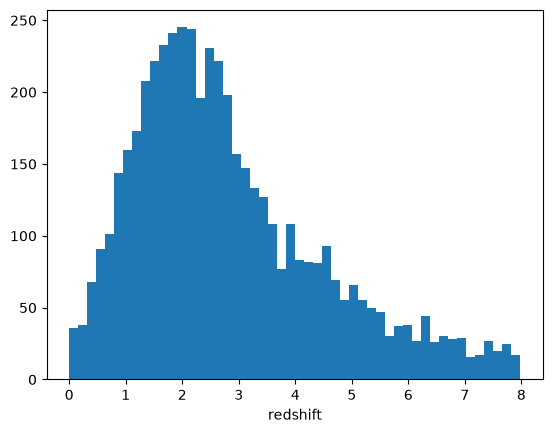

In [ ]:
plt.hist(snia_models.data["z"], bins = 50)
plt.xlabel("redshift")
# fig, axs = plt.subplots(2, 3, figsize =  (10, 5))
# axs[0,0].hist(snia_models.data["z"], bins=50)
# axs[0,0].set_xlabel('redshift')
# axs[0,0].set_ylabel('# SNIa events')

# axs[0,1].hist(snia_models.data["ra"], bins=50)
# axs[0,1].set_xlabel('ra')
# plt.tight_layout()

### Generate fixed parameters

{'redshift': {'func': <function fixed_param at 0x777da00aafb0>, 'kwargs': {'size': 1, 'value': 0.01}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x777da00aafb0>, 'kwargs': {'size': 1, 'value': -18.523}, 'as': 'magabs'}} <class 'dict'>
Skipping lsstz: outside model range.
Skipping lssty: outside model range.
valid bands are: ['lsstu', 'lsstg', 'lsstr', 'lssti']


/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)


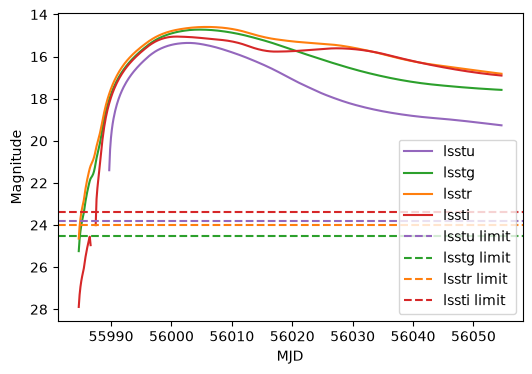

{'redshift': {'func': <function fixed_param at 0x777da00aafb0>, 'kwargs': {'size': 1, 'value': 0.5}, 'as': 'z'}, 'magabs': {'func': <function fixed_param at 0x777da00aafb0>, 'kwargs': {'size': 1, 'value': -18.523}, 'as': 'magabs'}} <class 'dict'>
valid bands are: ['lsstu', 'lsstg', 'lsstr', 'lssti', 'lsstz', 'lssty']


/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/sncosmo/models.py:189: RuntimeWarning: invalid value encountered in log10
  result[i] = -2.5 * np.log10(f / zpf)


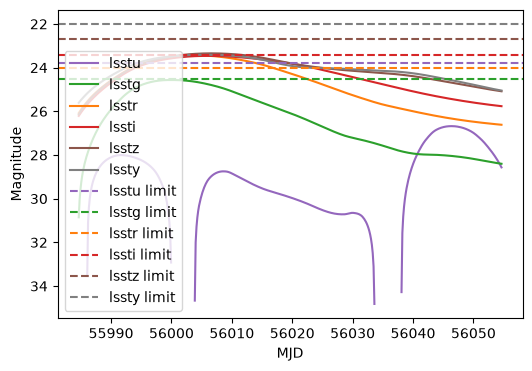

In [ ]:
snia_models = []
data_models = []
for redshift in [0.01, 0.5]:
    #keep the other params fixed
    snia_dict = None #initiate with None
    snia_dict = generate_snia_dict(ra = None, dec = None, redshift=redshift, x1 = None, magabs = -18.523, c = None)
    snia_param_list = generate_ordered_parameter_list(input_dict = True, params = snia_dict)
    snia_model, model_data = generate_snia_lightcurve(*snia_param_list, bands = bands, in_mag = True, plot_curve = True, return_values = True, return_models = True)
    snia_models.append(snia_model)
    data_models.append(model_data)

In [6]:
# input data points at every cadence.
# include a survey which gives you data points within this lc based on the pos in the sky
# and whether the obs

In [7]:
len(data_models)
visibility = determine_visibility(data_models[1])
visibility

,lsstu,lsstg,lsstr,lssti,lsstz,lssty
0,0,0,1,0,0,0


In [8]:
data_models[0]['times']
data_models[0]['lc_by_band']

{'lsstu': array([        nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan,         nan,         nan,         nan,         nan,
                nan, 21.39574764, 20.40739428, 19.86793492, 19.48967781,
        19.1964658 , 18.95653906, 18.75340311, 18.57481938, 18.41463507,
        18.26961984, 18.13737283, 18.01605704, 17.90423336, 17.80075177,
        17.70399617, 17.61271392, 17.52642024, 17.4446951 , 17.36717232,
        17.29353088, 17.22348792, 17.15671301, 17.09277301, 17.03137509,
        16.97227046, 16.91524416, 16.86010932, 16.80670251, 16.7549131 ,
        16.70471973, 16.65598585, 16.60858

In [9]:
data = data_models[0]
data

{'times': array([55984.6484375 , 55984.78871806, 55984.92899862, 55985.06927918,
        55985.20955974, 55985.34984031, 55985.49012087, 55985.63040143,
        55985.77068199, 55985.91096255, 55986.05124311, 55986.19152367,
        55986.33180423, 55986.47208479, 55986.61236536, 55986.75264592,
        55986.89292648, 55987.03320704, 55987.1734876 , 55987.31376816,
        55987.45404872, 55987.59432928, 55987.73460984, 55987.87489041,
        55988.01517097, 55988.15545153, 55988.29573209, 55988.43601265,
        55988.57629321, 55988.71657377, 55988.85685433, 55988.99713489,
        55989.13741546, 55989.27769602, 55989.41797658, 55989.55825714,
        55989.6985377 , 55989.83881826, 55989.97909882, 55990.11937938,
        55990.25965994, 55990.39994051, 55990.54022107, 55990.68050163,
        55990.82078219, 55990.96106275, 55991.10134331, 55991.24162387,
        55991.38190443, 55991.52218499, 55991.66246556, 55991.80274612,
        55991.94302668, 55992.08330724, 55992.2235878 ,

In [14]:
import pandas as pd
rows = []
# model is the skysurvey.core.target.Target, data is the y data
for model, data in zip(snia_models, data_models):
    vis = determine_visibility(lightcurves_data = data, return_dict = True) #this makes a dict
    row = {**{k: model.data[k][0] for k in snia_lightcurve_params}, **vis}
    rows.append(row)

df = pd.DataFrame(
    rows,
    index=[f"{i}" for i in range(len(data_models))],
    columns=snia_lightcurve_params + bands
)

df.index.name = "Target"
df

,z,x1,c,t0,magabs,ra,dec,lsstu,lsstg,lsstr,lssti,lsstz,lssty
Target,,,,,,,,,,,,,
0,0.01,-0.815,0.181,56004.648438,-18.523001,296.303864,73.764000,1,1,1,1,-1,-1
1,0.50,-1.420,0.076,56004.648438,-18.523001,328.342896,14.646819,0,0,1,0,0,0
